# 03 — Preprocessing

Notebook 02 produced **`TrainingDataset`s** — versioned snapshots of raw warehouse rows. This notebook turns one of those into a **`PreprocessedDataset`** ready to feed into a model.

## What preprocessing does (and what it deliberately doesn't)

`Preprocessor` is **stateless**: applying the same `FeatureSpec` to the same `TrainingDataset` always produces the same output, with no `.fit()` / `.transform()` asymmetry. v1 transforms are deterministic:

* **Pass-through features** — selected raw columns kept verbatim (`nasa_aod_550`, `merra_precipitable_water`, `clearness_index`, …).
* **Clear-sky index** — `kt = sat_ghi / sat_ghi_clear` for any `(ghi, ghi_clear)` pair you specify. CAMS ships `ghi_clear`, so kt against the CAMS satellite estimate is a one-line derivation. NASA POWER ships its own `clearness_index` directly so we just pass it through.
* **Cyclical day-of-year** — `(doy_sin, doy_cos)`. Adjacent calendar dates sit close in feature space; Dec 31 ↔ Jan 1 doesn't have to be re-learned by the model.
* **NaN drop** — rows with missing target or features get dropped. Imputation is left to model wrappers if their data argues for it.

What's **not** in `Preprocessor`:

* **Scaling** (StandardScaler / RobustScaler / …) — RF / XGBoost don't need it; NN models do, and only they know which fold to fit on. Scaling lives in the model wrapper (NB 04 / 05) where it can fit on the train fold without leakage.
* **Train/val/test splitting** — splitter design lives in NB 06 (currently a planned notebook; see this folder's README for status). The plan is to defer the `random / temporal / station-LOSO / spatial-block` choice to that stage so the splitter never leaks into preprocessing.
* **Lag features and station encodings** — added when concrete needs surface in NB 04 / 05, not pre-emptively.

## Persistence

`FeatureSpec` is a frozen dataclass with `to_json()` / `from_json()`. It travels alongside any model artifact so inference reconstructs identical transformations from a single JSON file — no joblib, no pickle.

In [1]:
import shutil
import shlex
import sys
import os

PROJECT_ID = "solar-irradiation-estimation"

if "google.colab" in sys.modules:
    # --- GOOGLE COLAB AUTOMATED SETUP ---
    REPO = "Marconi-Lab/Solar_irradiation"
    BRANCH = "jm/add_model"
    clone_url = f"https://github.com{REPO}.git"
    
    if not os.path.exists("/content/Solar_irradiation/.git"):
        get_ipython().system(f"git clone -q -b {BRANCH} {clone_url} /content/Solar_irradiation")

    get_ipython().run_line_magic('cd', '/content/Solar_irradiation')
    get_ipython().system('pip install -q -e . 2>&1 | tail -3')

    from google.colab import auth
    auth.authenticate_user()
    get_ipython().system(f'gcloud config set project {PROJECT_ID} 2>/dev/null')
    print("Colab setup complete.")

else:
    # --- LOCAL WSL / LINUX AUTOMATED SETUP ---
    print("Running in Local Linux/WSL Environment.")
    os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID
    
    # 1. Look for gcloud
    gcloud_path = shutil.which("gcloud")
    
    # Fallback check
    if not gcloud_path:
        home_bin = os.path.expanduser("~/google-cloud-sdk/bin/gcloud")
        if os.path.exists(home_bin):
            gcloud_path = home_bin

    # 2. Prevent installing if already found
    if not gcloud_path:
        print("SDK not found anywhere on the system. Installing now...")
        get_ipython().system('curl -sSL https://sdk.cloud.google.com | bash -s -- --disable-prompts > /dev/null')
        gcloud_path = os.path.expanduser("~/google-cloud-sdk/bin/gcloud")
    else:
        print(f"gcloud detected successfully at: {gcloud_path}")

    # FIXED: Use shlex.quote to safely wrap the windows/WSL path strings for Bash
    safe_gcloud_path = shlex.quote(gcloud_path)

    # 3. Trigger authentication using the safe, quoted path
    print("\nOpening your system browser for Google Cloud verification...")
    get_ipython().system(f'{safe_gcloud_path} auth application-default login')
    
    # 4. Set the project configuration
    get_ipython().system(f'{safe_gcloud_path} config set project {PROJECT_ID} 2>/dev/null')
    print(f"\nLocal setup complete! Active project set to: {PROJECT_ID}")

Running in Local Linux/WSL Environment.
gcloud detected successfully at: /mnt/c/Program Files (x86)/Google/Cloud SDK/google-cloud-sdk/bin/gcloud

Opening your system browser for Google Cloud verification...
Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=3GrbK9Q4tdQVHLIekt507r5tKFowmu&access_type=offline&code_challenge=tuGb4nmAOTERxmgB8c8tEDSHsib-jIRro0XcKbjsG8U&code_challenge_method=S256

gio: https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.goo

### Inputs, outputs, and prerequisites

| | |
|---|---|
| **Inputs** | A `TrainingDataset` snapshot from NB 02 (default: `data/training_snapshots/susse_training_demo_v1-2024/`). If absent, the notebook falls back to building a small one inline against the live warehouse. |
| **Outputs** | An in-memory `PreprocessedDataset` (X, y, feature names, source-dataset provenance) and a `FeatureSpec` JSON at `/tmp/feature_spec_v1.json`. NB 04 / 05 will pair this spec with each trained model artifact. |
| **Prereqs** | None for the loader path. The fallback path needs GCP credentials (same as NB 02). No W&B usage in this notebook. |
| **Consumed by** | NB 04 (models) reads `processed.X()` and `processed.y()`; NB 05 (training) wraps the same `Preprocessor` + `FeatureSpec` into the trained-model bundle. |

## 0 — Setup


In [2]:
%load_ext autoreload
%autoreload 2

import sys
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd

src_path = (Path.cwd() / "../../src").resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("Python", sys.version.split()[0])


Python 3.14.4


## 1 — Load (or build) a `TrainingDataset`

If you've run NB 02 and have a local snapshot, this loads it. Otherwise the cell builds a small one inline against the live warehouse so the rest of the notebook works.


In [3]:
from susse.datasets import (
    FeatureSelection, FeatureService, TrainingDataset,
    build_and_write_snapshot, load_snapshot,
)
from susse.warehouse_ops.io import BigQueryClient, TableRefs
from susse.warehouse_ops.population.types import Source

SNAPSHOT_ROOT = (Path.cwd() / "../../data/training_snapshots").resolve()
preferred_snapshot = SNAPSHOT_ROOT / "susse_training_demo_v1-2024"

if preferred_snapshot.exists():
    dataset = load_snapshot(preferred_snapshot)
    print(f"Loaded existing snapshot: {dataset.manifest.name} {dataset.manifest.version}")
else:
    print("No NB 02 snapshot found - building a small one inline.")
    bq = BigQueryClient()
    tables = TableRefs(config=bq.config)
    fs = FeatureService(bq=bq)
    selection = FeatureSelection(
        nasa_variable_ids=("aod_550", "precipitable_water", "cloud_amount", "clearness_index"),
        cams_variable_ids=("ghi_clear",),
        include_satellite_irradiance=(Source.NASA_POWER, Source.CAMS),
    )
    inline_dest = SNAPSHOT_ROOT / "_nb03_inline_demo"
    dataset = build_and_write_snapshot(
        feature_service=fs,
        selection=selection,
        date_start=date(2024, 1, 1),
        date_end=date(2024, 12, 31),
        locations=None,
        name="nb03_inline_demo",
        version="v0",
        dest=inline_dest,
    )
    print(f"Built {dataset.manifest.n_rows} rows x {dataset.manifest.n_cols} cols at {inline_dest}.")

print("Columns:", list(dataset.df.columns))

Loaded existing snapshot: susse_training_demo v1-2024
Columns: ['date', 'location', 'lat', 'lon', 'geohash5', 'y_ghi_kwh_m2_day', 'qc_level', 'sat_ghi_nasa_kwh_m2_day', 'sat_ghi_cams_kwh_m2_day', 'nasa_aod_550', 'nasa_precipitable_water', 'nasa_cloud_amount', 'nasa_clearness_index', 'cams_ghi_clear']


## 2 — Define a `FeatureSpec`

The recipe below is a sensible v1: aerosols + water vapour + cloudiness as pass-through features, NASA's `clearness_index` straight through (it's already kt), CAMS `kt_cams` derived from `(sat_ghi_cams, cams_ghi_clear)`, and the cyclical day-of-year encoding. All of this lives in this Python file (and therefore git) — change a feature → bump the model version.


### What goes into a `FeatureSpec`

The four fields below cover everything the preprocessor needs to know. **Every column name you reference must already exist in the loaded dataset** — see `dataset.df.columns` in the load-cell output above for the full list. A typo raises a `ValueError` at construction.

- **`target_column`** — the column the model will predict. Always `y_ghi_kwh_m2_day` here; that's the source-prefixed name `FeatureService` uses for the ground GHI target.
- **`feature_columns`** — raw columns kept verbatim. Pick from the `dataset.df.columns` list. Source-prefixed (`nasa_*`, `cams_*`, `merra_*`, `modis_*`) so adding a fifth source later won't collide.
- **`derived_features`** — a tuple of `DerivedFeature` instances. Each one declares its own output column(s), required input columns, and how to compute itself; the preprocessor iterates over the tuple and emits the columns in order. Concrete features available today:
  - `ClearSkyIndexFeature(ghi_column, ghi_clear_column, output_column)` — derives `kt = ghi / ghi_clear` for any `(GHI, clear-sky GHI)` pair. CAMS publishes `cams_ghi_clear` so we derive `kt_cams` below; NASA POWER pre-computes its own `clearness_index` (already kt), so we pass it through in `feature_columns` instead.
  - `CyclicalDayOfYearFeature()` — adds `doy_sin` and `doy_cos`. Drop from the tuple for an ablation that strips seasonality cues.
  - `AltitudeFeature(provider=...)` — looks up altitude in metres for every row's `(lat, lon)` via an injected `ElevationProvider` (e.g. `PvlibElevationProvider` over Open-Elevation). Not in this v1 spec; see `notebooks/papers/katongole_2023/` for the validation analysis that exercises it.
  - Adding a new derived feature is one new `DerivedFeature` subclass; `FeatureSpec` and `Preprocessor` themselves never change.
- **`id_columns`** — non-feature, non-target columns kept on `processed.df` for traceability (joining predictions back to dates / stations / coordinates). The model never sees these; `processed.X()` excludes them.

Two persistence-relevant defaults not shown above: `dropna_target=True` and `dropna_features=True` (rows with NaN in target or any feature get dropped). Imputation isn't a `Preprocessor` concern — RF / XGBoost handle NaN natively, and any model that needs imputation can wrap it on the fold-fitting side.

In [4]:
from susse.preprocessing import (
    ClearSkyIndexFeature,
    CyclicalDayOfYearFeature,
    FeatureSpec,
)

spec = FeatureSpec(
    target_column="y_ghi_kwh_m2_day",
    feature_columns=(
        "nasa_aod_550",
        "nasa_precipitable_water",
        "nasa_cloud_amount",
        "nasa_clearness_index",  # NASA's pre-computed kt — pass-through
        "sat_ghi_nasa_kwh_m2_day",
        "sat_ghi_cams_kwh_m2_day",
    ),
    derived_features=(
        ClearSkyIndexFeature(
            ghi_column="sat_ghi_cams_kwh_m2_day",
            ghi_clear_column="cams_ghi_clear",
            output_column="kt_cams",
        ),
        CyclicalDayOfYearFeature(),
    ),
    id_columns=("date", "location", "geohash5", "lat", "lon"),
)
print("Output features (in order):", spec.output_feature_names)
print("Target:", spec.target_column)

Output features (in order): ('nasa_aod_550', 'nasa_precipitable_water', 'nasa_cloud_amount', 'nasa_clearness_index', 'sat_ghi_nasa_kwh_m2_day', 'sat_ghi_cams_kwh_m2_day', 'kt_cams', 'doy_sin', 'doy_cos')
Target: y_ghi_kwh_m2_day


## 3 — Apply the preprocessor

`Preprocessor.apply` validates the input columns, runs the deterministic transforms, drops NaN rows per the policy, and returns a `PreprocessedDataset`.


In [5]:
from susse.preprocessing import Preprocessor

preprocessor = Preprocessor(spec)
processed = preprocessor.apply(dataset)

print(f"Source dataset:  {processed.source_dataset_name} {processed.source_dataset_version}")
print(f"  content hash:  {processed.source_content_hash[:16]}...")
print(f"Processed shape: {processed.n_rows} rows × {processed.n_features} features")
print(f"Feature columns: {processed.feature_columns}")
processed.df.head(3)


Source dataset:  susse_training_demo v1-2024
  content hash:  4e2df034e0036236...
Processed shape: 6776 rows × 9 features
Feature columns: ('nasa_aod_550', 'nasa_precipitable_water', 'nasa_cloud_amount', 'nasa_clearness_index', 'sat_ghi_nasa_kwh_m2_day', 'sat_ghi_cams_kwh_m2_day', 'kt_cams', 'doy_sin', 'doy_cos')


,date,location,geohash5,lat,lon,nasa_aod_550,nasa_precipitable_water,nasa_cloud_amount,nasa_clearness_index,sat_ghi_nasa_kwh_m2_day,sat_ghi_cams_kwh_m2_day,kt_cams,doy_sin,doy_cos,y_ghi_kwh_m2_day
0,2024-01-01,egypt_location1,str44,29.887561,32.460447,0.28,1.60,6.78,0.66,3.7332,3.712784,0.959547,0.0,1.0,3.128732
1,2024-01-01,ghana_location1,ecpbj,5.645759,-0.105223,0.57,4.28,8.20,0.58,5.3671,5.420120,0.954389,0.0,1.0,4.246611
2,2024-01-01,ghana_location2,s1000,5.645686,0.008678,0.57,4.23,5.13,0.53,4.8605,5.340148,0.959209,0.0,1.0,4.179786


A quick check on dropped rows: how many input rows had missing target or features and got removed by the NaN policy?


In [6]:
n_in = len(dataset.df)
n_out = processed.n_rows
print(f"Input  rows: {n_in:,}")
print(f"Output rows: {n_out:,}")
print(f"Dropped:     {n_in - n_out:,} ({100 * (n_in - n_out) / n_in:.1f}%)")


Input  rows: 6,776
Output rows: 6,776
Dropped:     0 (0.0%)


## 4 — Inspect the model-input slice

`processed.X()` returns the feature DataFrame in the spec's column order. `processed.y()` returns the target series. This is the contract the model layer (NB 04) consumes.


In [7]:
X = processed.X()
y = processed.y()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
X.describe().T[["count", "mean", "std", "min", "max"]]


X shape: (6776, 9)
y shape: (6776,)


,count,mean,std,min,max
nasa_aod_550,6776.0,0.326641,0.223591,0.000000,2.740000
nasa_precipitable_water,6776.0,3.267894,1.189321,0.600000,6.600000
nasa_cloud_amount,6776.0,57.443539,28.947423,0.030000,99.910000
nasa_clearness_index,6776.0,0.558062,0.115832,0.070000,0.790000
sat_ghi_nasa_kwh_m2_day,6776.0,5.466409,1.227093,0.755000,8.851900
sat_ghi_cams_kwh_m2_day,6776.0,5.656317,1.541307,0.838221,8.951160
kt_cams,6776.0,0.785835,0.191951,0.119596,1.000000
doy_sin,6776.0,0.038318,0.738371,-0.999963,0.999963
doy_cos,6776.0,-0.136096,0.659517,-1.000000,1.000000


A quick sanity-check on the derived kt column: physically, daily kt for sub-Saharan Africa typically sits between ~0.3 (overcast) and ~0.85 (very clear day), with a typical mean around 0.6–0.7. Values near or above 1.0 happen during cloud-edge enhancement and are real but rare.


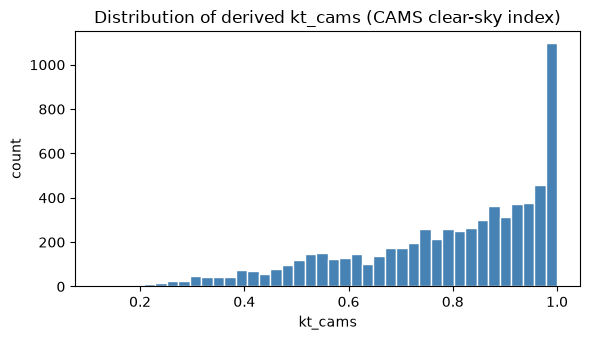

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(processed.df["kt_cams"].dropna(), bins=40, color="steelblue", edgecolor="white")
ax.set_xlabel("kt_cams")
ax.set_ylabel("count")
ax.set_title("Distribution of derived kt_cams (CAMS clear-sky index)")
plt.tight_layout()


And the cyclical day-of-year encoding — a quick sanity plot to confirm we're getting a circle in (sin, cos) space, not a ramp.


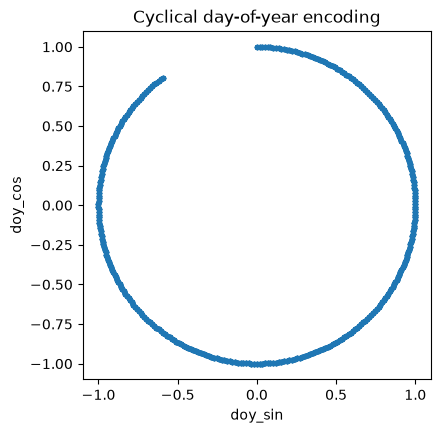

In [9]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(processed.df["doy_sin"], processed.df["doy_cos"], s=8, alpha=0.5)
ax.set_xlabel("doy_sin")
ax.set_ylabel("doy_cos")
ax.set_title("Cyclical day-of-year encoding")
ax.set_aspect("equal")
plt.tight_layout()


## 5 — Persist the spec

The `FeatureSpec` JSON is the only state the preprocessor needs. NB 04 / 05 will save it next to each trained model so inference reconstructs identical transformations from a single small file.


In [10]:
import json

spec_path = Path("/tmp/feature_spec_v1.json")
spec_path.write_text(spec.to_json())
print(f"Wrote {spec_path} ({spec_path.stat().st_size} bytes)")

# Roundtrip verification: from-json back to FeatureSpec equals the original.
recovered = FeatureSpec.from_json(spec_path.read_text())
assert recovered == spec
print("FeatureSpec JSON roundtrip OK.")
print(json.dumps(recovered.to_dict(), indent=2)[:600])


Wrote /tmp/feature_spec_v1.json (632 bytes)
FeatureSpec JSON roundtrip OK.
{
  "target_column": "y_ghi_kwh_m2_day",
  "feature_columns": [
    "nasa_aod_550",
    "nasa_precipitable_water",
    "nasa_cloud_amount",
    "nasa_clearness_index",
    "sat_ghi_nasa_kwh_m2_day",
    "sat_ghi_cams_kwh_m2_day"
  ],
  "cleaners": [],
  "derived_features": [
    {
      "kind": "clear_sky_index",
      "ghi_column": "sat_ghi_cams_kwh_m2_day",
      "ghi_clear_column": "cams_ghi_clear",
      "output_column": "kt_cams"
    },
    {
      "kind": "cyclical_doy"
    }
  ],
  "id_columns": [
    "date",
    "location",
    "geohash5",
    "lat",
    "lon"
  ],
  "dropna_target": t


## What's next

* **NB 04 — `04_models.ipynb`** — `BaseRegressor` ABC, `ModelFactory`, RF baseline + a stub second model. Each model class accepts a `PreprocessedDataset` (or its `X` / `y` slices), wires its own scaling on the train fold, and persists its weights + the parent `FeatureSpec` together.
* **NB 06** — splitter design (random / temporal / station-LOSO / spatial-block) decides what "train fold" actually means for fitting scalers and validating models.

The discipline going forward:

| Change | What ripples |
|---|---|
| Add a kt feature | Append a new `ClearSkyIndexFeature` to `derived_features` → re-preprocess → retrain → bump model version |
| Add a new feature kind (e.g. distance-to-coast) | One new `DerivedFeature` subclass; `FeatureSpec` and `Preprocessor` don't change. Add to `derived_features` → re-preprocess → retrain |
| Drop a feature for an ablation | Derived `FeatureSpec` (omit the entry) → re-preprocess → train alongside |
| Switch clear-sky reference | New `ClearSkyIndexFeature` (different `ghi_clear_column`) → re-preprocess → retrain |
| Tweak NaN policy | New spec (different dropna flags) → re-preprocess; depending on data, might require a fresh `TrainingDataset` |

The `FeatureSpec` is never edited in place — that would silently change what an existing model artifact's "training distribution" was.